In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import torch
from torch.utils.data import Dataset
import pandas as pd
import numpy as np

LABEL_MAP = {
    'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4,  'F': 5,
    'G': 6, 'H': 7, 'I': 8, 'J': 9, 'K': 10, 'L': 11,
    'M': 12,'O': 13,'P': 14,'Q': 15,'R': 16, 'S': 17
}

class MoveDataset(Dataset):
    def __init__(self, base_path, subjects):
        wa = pd.read_parquet(f"{base_path}/watch_accel/")
        wg = pd.read_parquet(f"{base_path}/watch_gyro/")
        pa = pd.read_parquet(f"{base_path}/phone_accel/")
        pg = pd.read_parquet(f"{base_path}/phone_gyro/")

        wa = wa[wa["subject_id"].isin(subjects)]
        wg = wg[wg["subject_id"].isin(subjects)]
        pa = pa[pa["subject_id"].isin(subjects)]
        pg = pg[pg["subject_id"].isin(subjects)]

        keys = ["subject_id", "activity_label", "window_index"]
        merged = (wa.merge(wg, on=keys, suffixes=("_wa", "_wg"))
                    .merge(pa, on=keys, suffixes=("", "_pa"))
                    .merge(pg, on=keys, suffixes=("", "_pg")))

        self.data   = merged.reset_index(drop=True)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]

        wa = np.array(list(row["wa_features"]), dtype=np.float32)
        wg = np.array(list(row["wg_features"]), dtype=np.float32)
        pa = np.array(list(row["pa_features"]), dtype=np.float32)
        pg = np.array(list(row["pg_features"]), dtype=np.float32)

        x = np.concatenate([wa, wg, pa, pg], axis=1)
        x = torch.tensor(x).permute(1, 0)

        y = torch.tensor(LABEL_MAP[row["activity_label"]], dtype=torch.long)

        return x, y

In [ ]:
from torch.utils.data import DataLoader

all_subjects = list(range(1600, 1651))

train_subjects = all_subjects[:40]
val_subjects   = all_subjects[40:46]
test_subjects  = all_subjects[46:]

base_path = "/content/drive/MyDrive/DSE 230/final project/windowed"

train_ds = MoveDataset(base_path, train_subjects)
val_ds   = MoveDataset(base_path, val_subjects)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False)

print(f"Train windows : {len(train_ds)}")
print(f"Val windows   : {len(val_ds)}")

Train windows : 24307
Val windows   : 3447


In [ ]:
import torch
import torch.nn as nn

class CNN_LSTM(nn.Module):
    def __init__(self, n_channels=12, n_classes=18):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv1d(n_channels, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            nn.Conv1d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
        )

        self.lstm = nn.LSTM(
            input_size=128,
            hidden_size=128,
            num_layers=2,
            batch_first=True,
            dropout=0.6,
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        x = self.cnn(x)
        x = x.permute(0, 2, 1)
        _, (h, _) = self.lstm(x)
        x = h[-1]
        x = self.classifier(x)
        return x



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = CNN_LSTM(n_channels=12, n_classes=18).to(device)
print(model)

Using device: cuda
CNN_LSTM(
  (cnn): Sequential(
    (0): Conv1d(12, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (7): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
  )
  (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.6)
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=128, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=18, bias=True)
  )
)


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss   = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct    += (logits.argmax(dim=1) == y).sum().item()
        total      += len(y)

    return total_loss / len(loader), correct / total


def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss   = criterion(logits, y)

            total_loss += loss.item()
            correct    += (logits.argmax(dim=1) == y).sum().item()
            total      += len(y)

    return total_loss / len(loader), correct / total

In [ ]:
N_EPOCHS = 30

best_val_acc = 0
patience_counter = 0
PATIENCE = 8

for epoch in range(N_EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc     = eval_epoch(model, val_loader, criterion)

    print(f"Epoch {epoch+1:02d}/{N_EPOCHS} | "
          f"Train loss: {train_loss:.4f}  acc: {train_acc:.4f} | "
          f"Val loss: {val_loss:.4f}  acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pt")
        patience_counter = 0
        print(f"  Best model saved (val acc: {val_acc:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping — best val acc: {best_val_acc:.4f}")
            break

Epoch 01/30 | Train loss: 2.1357  acc: 0.2626 | Val loss: 1.9385  acc: 0.3270
  Best model saved (val acc: 0.3270)
Epoch 02/30 | Train loss: 1.7621  acc: 0.3748 | Val loss: 1.6666  acc: 0.4288
  Best model saved (val acc: 0.4288)
Epoch 03/30 | Train loss: 1.5772  acc: 0.4454 | Val loss: 1.6201  acc: 0.4703
  Best model saved (val acc: 0.4703)
Epoch 04/30 | Train loss: 1.4142  acc: 0.5036 | Val loss: 1.5277  acc: 0.4732
  Best model saved (val acc: 0.4732)
Epoch 05/30 | Train loss: 1.2985  acc: 0.5470 | Val loss: 1.5626  acc: 0.5036
  Best model saved (val acc: 0.5036)
Epoch 06/30 | Train loss: 1.1838  acc: 0.5807 | Val loss: 1.5436  acc: 0.4999
Epoch 07/30 | Train loss: 1.0796  acc: 0.6226 | Val loss: 1.4350  acc: 0.5596
  Best model saved (val acc: 0.5596)
Epoch 08/30 | Train loss: 0.9709  acc: 0.6575 | Val loss: 1.5574  acc: 0.5431
Epoch 09/30 | Train loss: 0.8967  acc: 0.6847 | Val loss: 1.5073  acc: 0.5718
  Best model saved (val acc: 0.5718)
Epoch 10/30 | Train loss: 0.8475  acc: 

In [ ]:
del train_ds, val_ds, train_loader, val_loader

In [ ]:
test_ds  = MoveDataset(base_path, test_subjects)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False)

Test accuracy: 0.7390

Per-activity breakdown:
              precision    recall  f1-score   support

           A       0.84      0.83      0.83       173
           B       0.99      0.98      0.98       173
           C       0.78      0.83      0.81       174
           D       0.51      0.70      0.59       172
           E       0.95      0.82      0.88       173
           F       0.63      0.99      0.77       172
           G       1.00      0.94      0.97       172
           H       0.84      0.46      0.60       173
           I       0.47      0.61      0.53       172
           J       0.74      0.47      0.57       172
           K       0.47      0.61      0.53       173
           L       0.05      0.03      0.04       172
           M       0.82      0.89      0.85       172
           O       0.92      0.82      0.87       172
           P       0.88      1.00      0.94       173
           Q       0.69      0.59      0.64       172
           R       0.97      0.94 

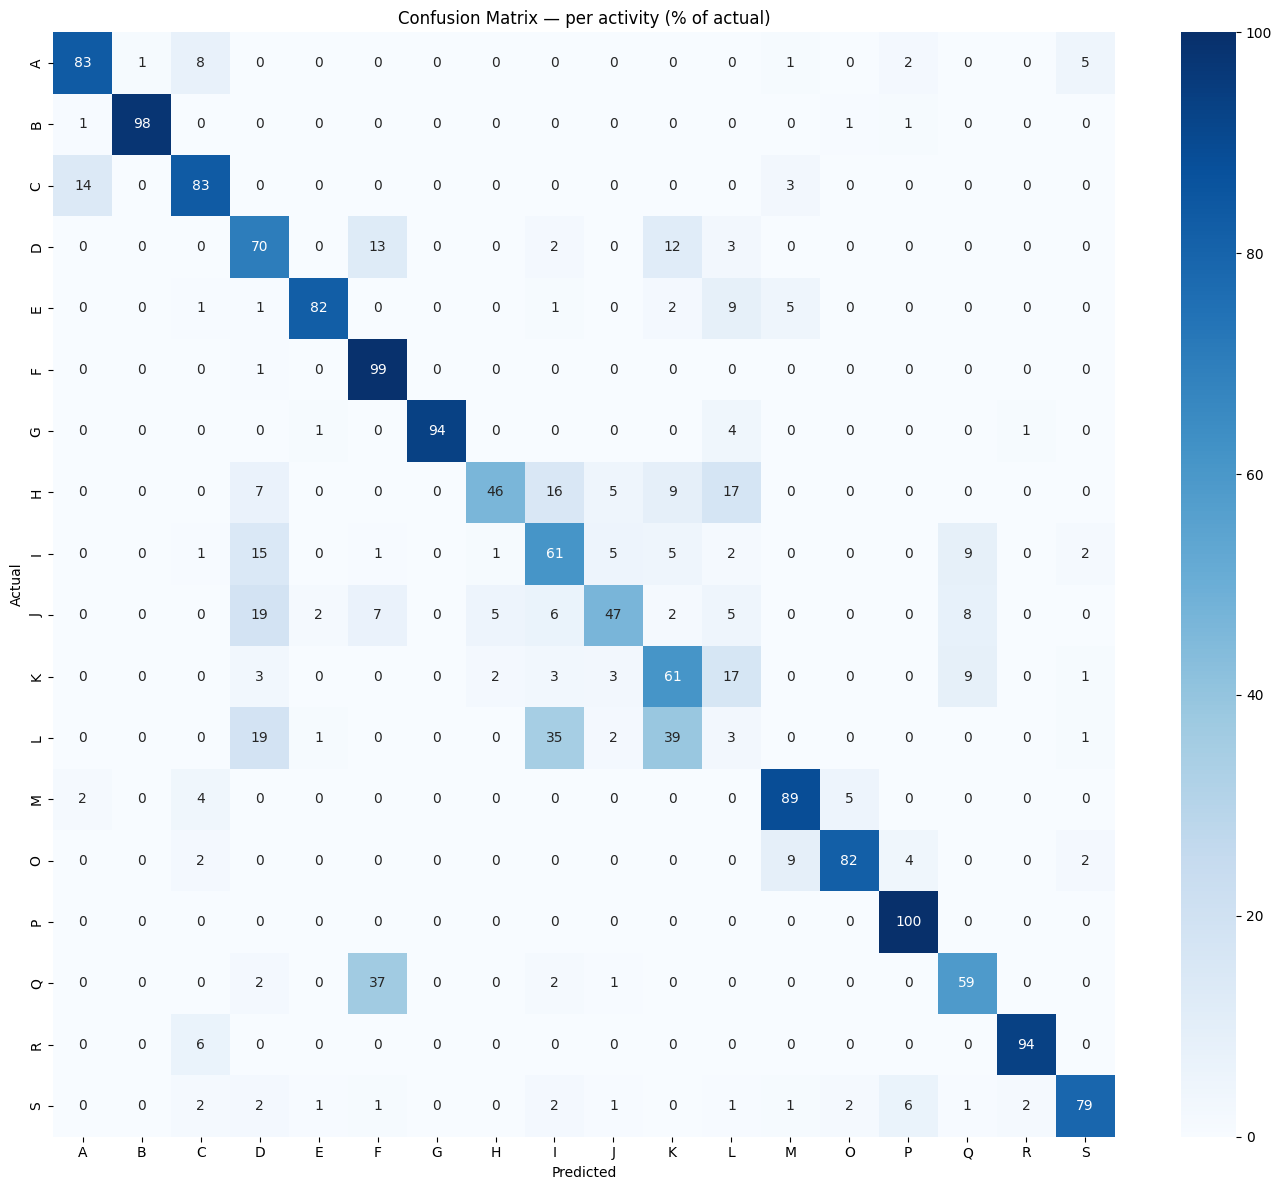

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch

ACTIVITY_NAMES = {
    0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E',  5: 'F',
    6: 'G', 7: 'H', 8: 'I', 9: 'J', 10: 'K', 11: 'L',
    12: 'M', 13: 'O', 14: 'P', 15: 'Q', 16: 'R', 17: 'S'
}

model.load_state_dict(torch.load("best_model.pt"))
model.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for x, y in test_loader:
        x, y   = x.to(device), y.to(device)
        logits = model(x)
        preds  = logits.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

test_acc = (all_preds == all_labels).mean()
print(f"Test accuracy: {test_acc:.4f}")
print("\nPer-activity breakdown:")
print(classification_report(
    all_labels, all_preds,
    target_names=list(ACTIVITY_NAMES.values())
))

cm = confusion_matrix(all_labels, all_preds)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm_pct,
    annot=True, fmt=".0f",
    xticklabels=list(ACTIVITY_NAMES.values()),
    yticklabels=list(ACTIVITY_NAMES.values()),
    cmap="Blues", vmin=0, vmax=100
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — per activity (% of actual)")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()